<a href="https://colab.research.google.com/github/KavindaKGD/Franklin-Models/blob/Siamese/Siamese%2BResNet_18.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import os, random, itertools
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("TF:", tf.__version__)


TF: 2.19.0


In [ ]:
from google.colab import drive
drive.mount("/content/drive")


Mounted at /content/drive


In [ ]:
DATA_ROOT = "/content/drive/MyDrive/fp_dataset"
TRAIN_DIR = os.path.join(DATA_ROOT, "train")
VAL_DIR   = os.path.join(DATA_ROOT, "val")

CLASS_NAMES = ["fp", "healthy", "barnacles"]  # must match folder names exactly

print("Train dir:", TRAIN_DIR)
print("Val dir:", VAL_DIR)

for c in CLASS_NAMES:
    print(c, "train:", len(os.listdir(os.path.join(TRAIN_DIR, c))),
             "val:", len(os.listdir(os.path.join(VAL_DIR, c))))


Train dir: /content/drive/MyDrive/fp_dataset/train
Val dir: /content/drive/MyDrive/fp_dataset/val
fp train: 4 val: 2
healthy train: 4 val: 2
barnacles train: 4 val: 2


In [ ]:
def list_images_and_labels(base_dir, class_names):
    paths, labels = [], []
    for idx, cname in enumerate(class_names):
        cdir = os.path.join(base_dir, cname)
        for fname in os.listdir(cdir):
            if fname.lower().endswith((".jpg", ".jpeg", ".png", ".webp")):
                paths.append(os.path.join(cdir, fname))
                labels.append(idx)
    return paths, labels

train_paths, train_labels = list_images_and_labels(TRAIN_DIR, CLASS_NAMES)
val_paths, val_labels     = list_images_and_labels(VAL_DIR, CLASS_NAMES)

print("Train images:", len(train_paths))
print("Val images:", len(val_paths))


Train images: 12
Val images: 6


In [ ]:
def make_pairs(paths, labels):
    by_class = {}
    for p, y in zip(paths, labels):
        by_class.setdefault(y, []).append(p)

    # positive pairs
    pos_pairs = []
    for y, plist in by_class.items():
        for a, b in itertools.combinations(plist, 2):
            pos_pairs.append((a, b, 1))

    # negative pairs
    neg_pairs = []
    classes = list(by_class.keys())
    for i in range(len(classes)):
        for j in range(i+1, len(classes)):
            c1, c2 = classes[i], classes[j]
            for a in by_class[c1]:
                for b in by_class[c2]:
                    neg_pairs.append((a, b, 0))

    random.shuffle(pos_pairs)
    random.shuffle(neg_pairs)

    n = min(len(pos_pairs), len(neg_pairs))
    pairs = pos_pairs[:n] + neg_pairs[:n]
    random.shuffle(pairs)

    x1 = [p[0] for p in pairs]
    x2 = [p[1] for p in pairs]
    y  = np.array([p[2] for p in pairs], dtype=np.float32)
    return x1, x2, y

train_x1, train_x2, train_y = make_pairs(train_paths, train_labels)
val_x1, val_x2, val_y       = make_pairs(val_paths, val_labels)

print("Train pairs:", len(train_y), "| Pos:", int(train_y.sum()), "| Neg:", int((1-train_y).sum()))
print("Val pairs:", len(val_y), "| Pos:", int(val_y.sum()), "| Neg:", int((1-val_y).sum()))


Train pairs: 36 | Pos: 18 | Neg: 18
Val pairs: 6 | Pos: 3 | Neg: 3


In [ ]:
IMG_SIZE = 224
BATCH_SIZE = 16

data_augment = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.05),
    tf.keras.layers.RandomZoom(0.10),
])

def load_image(path):
    img = tf.io.read_file(path)
    img = tf.image.decode_image(img, channels=3, expand_animations=False)
    img = tf.image.resize(img, (IMG_SIZE, IMG_SIZE))
    img = tf.cast(img, tf.float32) / 255.0
    return img

def make_dataset(x1, x2, y, training=True):
    ds = tf.data.Dataset.from_tensor_slices((x1, x2, y))

    def _map(a, b, label):
        ia = load_image(a)
        ib = load_image(b)
        if training:
            ia = data_augment(ia, training=True)
            ib = data_augment(ib, training=True)
        return (ia, ib), label

    ds = ds.map(_map, num_parallel_calls=tf.data.AUTOTUNE)
    if training:
        ds = ds.shuffle(512, seed=SEED, reshuffle_each_iteration=True)
    ds = ds.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)
    return ds

train_ds = make_dataset(train_x1, train_x2, train_y, training=True)
val_ds   = make_dataset(val_x1, val_x2, val_y, training=False)


In [ ]:
def resnet_basic_block(x, filters, stride=1, name="block"):
    shortcut = x

    x = tf.keras.layers.Conv2D(filters, 3, strides=stride, padding="same",
                               use_bias=False, name=name+"_conv1")(x)
    x = tf.keras.layers.BatchNormalization(name=name+"_bn1")(x)
    x = tf.keras.layers.ReLU(name=name+"_relu1")(x)

    x = tf.keras.layers.Conv2D(filters, 3, strides=1, padding="same",
                               use_bias=False, name=name+"_conv2")(x)
    x = tf.keras.layers.BatchNormalization(name=name+"_bn2")(x)

    if stride != 1 or shortcut.shape[-1] != filters:
        shortcut = tf.keras.layers.Conv2D(filters, 1, strides=stride, padding="same",
                                          use_bias=False, name=name+"_down_conv")(shortcut)
        shortcut = tf.keras.layers.BatchNormalization(name=name+"_down_bn")(shortcut)

    x = tf.keras.layers.Add(name=name+"_add")([x, shortcut])
    x = tf.keras.layers.ReLU(name=name+"_out")(x)
    return x

def build_resnet18_encoder(embedding_dim=128, dropout=0.2):
    inp = tf.keras.Input(shape=(IMG_SIZE, IMG_SIZE, 3), name="image")

    # Stem
    x = tf.keras.layers.Conv2D(64, 7, strides=2, padding="same", use_bias=False, name="stem_conv")(inp)
    x = tf.keras.layers.BatchNormalization(name="stem_bn")(x)
    x = tf.keras.layers.ReLU(name="stem_relu")(x)
    x = tf.keras.layers.MaxPool2D(pool_size=3, strides=2, padding="same", name="stem_pool")(x)

    # [2,2,2,2]
    x = resnet_basic_block(x, 64,  stride=1, name="s1_b1")
    x = resnet_basic_block(x, 64,  stride=1, name="s1_b2")

    x = resnet_basic_block(x, 128, stride=2, name="s2_b1")
    x = resnet_basic_block(x, 128, stride=1, name="s2_b2")

    x = resnet_basic_block(x, 256, stride=2, name="s3_b1")
    x = resnet_basic_block(x, 256, stride=1, name="s3_b2")

    x = resnet_basic_block(x, 512, stride=2, name="s4_b1")
    x = resnet_basic_block(x, 512, stride=1, name="s4_b2")

    x = tf.keras.layers.GlobalAveragePooling2D(name="gap")(x)
    if dropout and dropout > 0:
        x = tf.keras.layers.Dropout(dropout, name="drop")(x)

    x = tf.keras.layers.Dense(embedding_dim, name="emb_dense")(x)

    # ✅ Keras-safe L2 normalize
    out = tf.keras.layers.Lambda(lambda t: tf.math.l2_normalize(t, axis=-1),
                                 name="l2norm")(x)

    return tf.keras.Model(inp, out, name="ResNet18_Encoder")

backbone = build_resnet18_encoder(embedding_dim=128, dropout=0.2)
backbone.summary()


Model: "ResNet18_Encoder"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ image (InputLayer)  │ (None, 224, 224,  │          0 │ -                 │
│                     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv (Conv2D)  │ (None, 112, 112,  │      9,408 │ image[0][0]       │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_bn             │ (None, 112, 112,  │        256 │ stem_conv[0][0]   │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_relu (ReLU)    │ (None, 112, 112,  │          0 │ stem_bn[0][0]     │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_pool           │ (None, 56, 56,    │          0 │ stem_relu[0][0]   │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ s1_b1_conv1         │ (None, 56, 56,    │     36,864 │ stem_pool[0][0]   │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ s1_b1_bn1           │ (None, 56, 56,    │        256 │ s1_b1_conv1[0][0] │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ s1_b1_relu1 (ReLU)  │ (None, 56, 56,    │          0 │ s1_b1_bn1[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ s1_b1_conv2         │ (None, 56, 56,    │     36,864 │ s1_b1_relu1[0][0] │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ s1_b1_bn2           │ (None, 56, 56,    │        256 │ s1_b1_conv2[0][0] │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ s1_b1_add (Add)     │ (None, 56, 56,    │          0 │ s1_b1_bn2[0][0],  │
│                     │ 64)               │            │ stem_pool[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ s1_b1_out (ReLU)    │ (None, 56, 56,    │          0 │ s1_b1_add[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ s1_b2_conv1         │ (None, 56, 56,    │     36,864 │ s1_b1_out[0][0]   │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ s1_b2_bn1           │ (None, 56, 56,    │        256 │ s1_b2_conv1[0][0] │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ s1_b2_relu1 (ReLU)  │ (None, 56, 56,    │          0 │ s1_b2_bn1[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ s1_b2_conv2         │ (None, 56, 56,    │     36,864 │ s1_b2_relu1[0][0] │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ s1_b2_bn2           │ (None, 56, 56,    │        256 │ s1_b2_conv2[0][0

 Total params: 11,251,776 (42.92 MB)

 Trainable params: 11,242,176 (42.89 MB)

 Non-trainable params: 9,600 (37.50 KB)

In [ ]:
def build_siamese(backbone):
    img_a = tf.keras.Input(shape=(IMG_SIZE, IMG_SIZE, 3), name="img_a")
    img_b = tf.keras.Input(shape=(IMG_SIZE, IMG_SIZE, 3), name="img_b")

    emb_a = backbone(img_a)
    emb_b = backbone(img_b)

    # L1 distance between embeddings
    diff = tf.keras.layers.Lambda(lambda t: tf.abs(t[0] - t[1]))([emb_a, emb_b])

    x = tf.keras.layers.Dense(128, activation="relu")(diff)
    x = tf.keras.layers.Dropout(0.3)(x)
    out = tf.keras.layers.Dense(1, activation="sigmoid")(x)

    return tf.keras.Model([img_a, img_b], out, name="Siamese_ResNet18")

siamese = build_siamese(backbone)
siamese.summary()

siamese.compile(
    optimizer=tf.keras.optimizers.Adam(1e-4),
    loss=tf.keras.losses.BinaryCrossentropy(),
    metrics=[
        tf.keras.metrics.BinaryAccuracy(name="acc"),
        tf.keras.metrics.AUC(name="auc")
    ]
)


Model: "Siamese_ResNet18"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ img_a (InputLayer)  │ (None, 224, 224,  │          0 │ -                 │
│                     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ img_b (InputLayer)  │ (None, 224, 224,  │          0 │ -                 │
│                     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ ResNet18_Encoder    │ (None, 128)       │ 11,251,776 │ img_a[0][0],      │
│ (Functional)        │                   │            │ img_b[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda (Lambda)     │ (None, 128)       │          0 │ ResNet18_Encoder… │
│                     │                   │            │ ResNet18_Encoder… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 128)       │     16,512 │ lambda[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 128)       │          0 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 1)         │        129 │ dropout[0][0]     │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 11,268,417 (42.99 MB)

 Trainable params: 11,258,817 (42.95 MB)

 Non-trainable params: 9,600 (37.50 KB)

In [ ]:
callbacks = [
    tf.keras.callbacks.EarlyStopping(patience=12, restore_best_weights=True),
    tf.keras.callbacks.ReduceLROnPlateau(patience=6, factor=0.5, verbose=1),
]

history = siamese.fit(
    train_ds,
    validation_data=val_ds,
    epochs=80,
    callbacks=callbacks
)


Epoch 1/80
3/3 ━━━━━━━━━━━━━━━━━━━━ 57s 11s/step - acc: 0.5000 - auc: 0.4510 - loss: 0.6959 - val_acc: 0.5000 - val_auc: 0.7778 - val_loss: 0.6917 - learning_rate: 1.0000e-04
Epoch 2/80
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 168ms/step - acc: 0.5095 - auc: 0.6635 - loss: 0.6824 - val_acc: 0.5000 - val_auc: 0.6667 - val_loss: 0.6919 - learning_rate: 1.0000e-04
Epoch 3/80
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 163ms/step - acc: 0.5095 - auc: 0.7178 - loss: 0.6673 - val_acc: 0.5000 - val_auc: 0.6667 - val_loss: 0.6932 - learning_rate: 1.0000e-04
Epoch 4/80
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 127ms/step - acc: 0.5590 - auc: 0.7784 - loss: 0.6725 - val_acc: 0.6667 - val_auc: 0.5000 - val_loss: 0.6931 - learning_rate: 1.0000e-04
Epoch 5/80
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 130ms/step - acc: 0.6198 - auc: 0.7294 - loss: 0.6676 - val_acc: 0.8333 - val_auc: 0.5000 - val_loss: 0.6927 - learning_rate: 1.0000e-04
Epoch 6/80
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 129ms/step - acc: 0.5217 - auc: 0.8021 - loss: 0.6738 - val_acc: 0.5000 - val_auc:

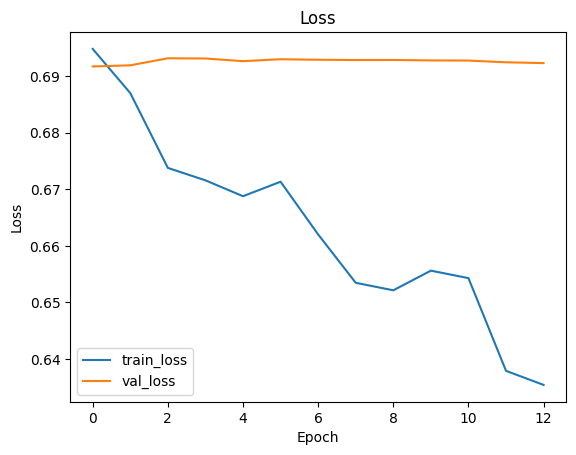

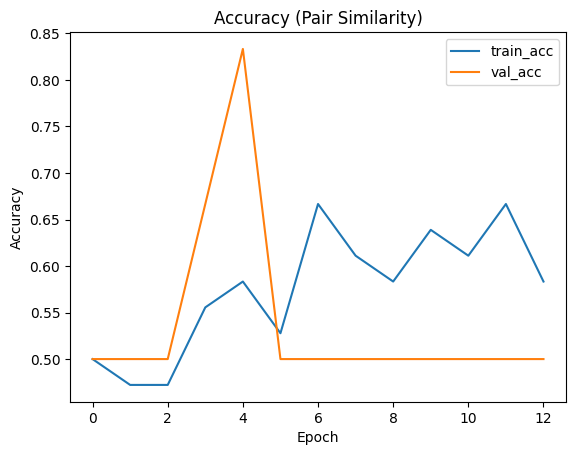

In [ ]:
def plot_history(hist):
    h = hist.history

    plt.figure()
    plt.plot(h["loss"], label="train_loss")
    plt.plot(h["val_loss"], label="val_loss")
    plt.title("Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()
    plt.show()

    plt.figure()
    plt.plot(h["acc"], label="train_acc")
    plt.plot(h["val_acc"], label="val_acc")
    plt.title("Accuracy (Pair Similarity)")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.legend()
    plt.show()

plot_history(history)


In [ ]:
SAVE_DIR = "/content/drive/MyDrive/sea_turtle_models"
os.makedirs(SAVE_DIR, exist_ok=True)

SIAMESE_PATH  = os.path.join(SAVE_DIR, "siamese_resnet18.keras")
BACKBONE_PATH = os.path.join(SAVE_DIR, "resnet18_encoder.keras")

siamese.save(SIAMESE_PATH)
backbone.save(BACKBONE_PATH)

print("Saved Siamese:", SIAMESE_PATH)
print("Saved Backbone:", BACKBONE_PATH)


Saved Siamese: /content/drive/MyDrive/sea_turtle_models/siamese_resnet18.keras
Saved Backbone: /content/drive/MyDrive/sea_turtle_models/resnet18_encoder.keras
